Perceptron algorithm in Python

The perceptron was one of the first neutral networks created. It is designed to be a binary classifier of linearly separable data.

Part A: dataset

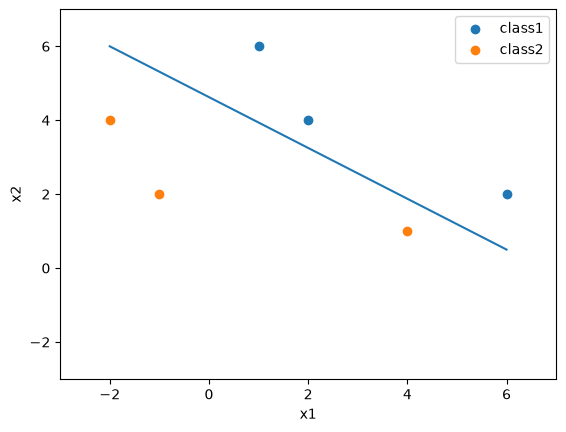

In [67]:
import numpy as np
import matplotlib.pyplot as plt

MAX = 45 

data = np.array([
    [-2,4,1],
    [4,1,1],
    [-1,2,1],
    [1, 6, 1],
    [2, 4, 1],
    [6, 2, 1],
])
label = np.array([-1,-1,-1,1,1,1])

class_1 = data[label == 1]
class_2 = data[label == -1]

#plot class 1
plt.scatter(class_1[:,0], class_1[:,1], label = 'class1')  
 
#plot class 2
plt.scatter(class_2[:,0], class_2[:,1], label = 'class2')  

#possible hyperplane
plt.plot([-2, 6],[6, 0.5])

plt.xlabel('x1')
plt.ylabel('x2')
plt.xlim(-3, 7)
plt.ylim(-3, 7)
plt.legend()
plt.show()

The choosen separating hyperplane: w = (0.6875,1) b = -4.625 is a potential hyperplane; out of an infinite number of possible planes; that accurately separates the data into class1 and class2. The goal of the perceptron is to produce a hyperplane like this one using only the data points and their known class.

mistake:     [1 6 1]
new weight:  [1. 6. 1.]


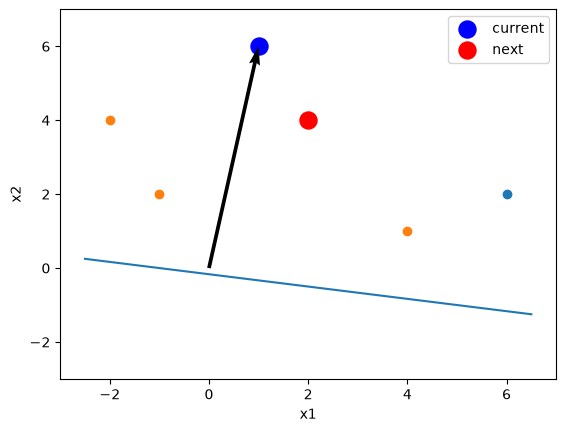

mistake:     [-2  4  1]
new weight:  [3. 2. 0.]


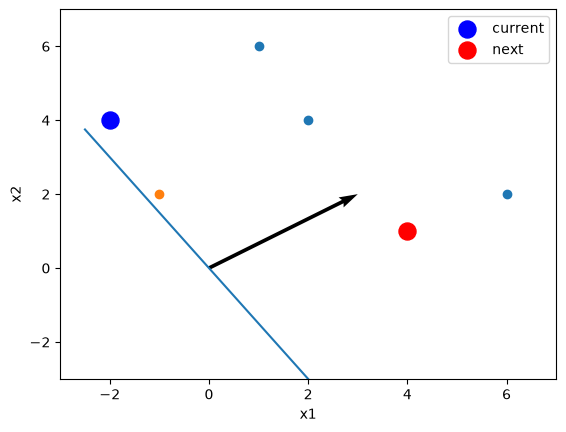

mistake:     [4 1 1]
new weight:  [-1.  1. -1.]


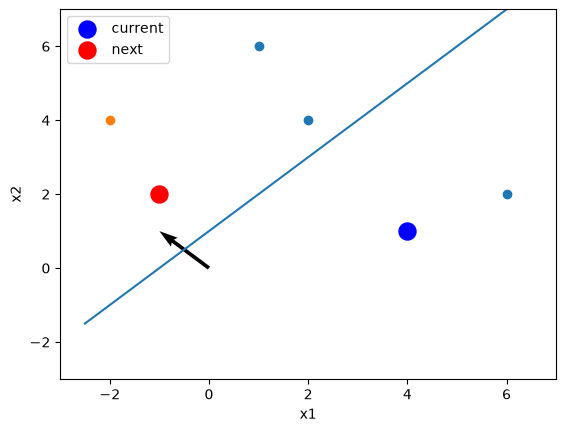

mistake:     [-1  2  1]
new weight:  [ 0. -1. -2.]


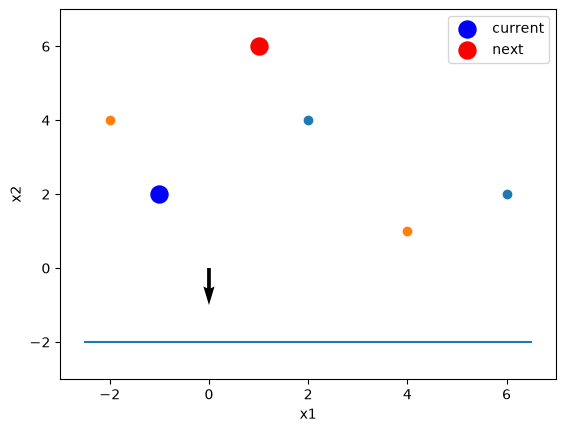

mistake:     [1 6 1]
new weight:  [ 1.  5. -1.]


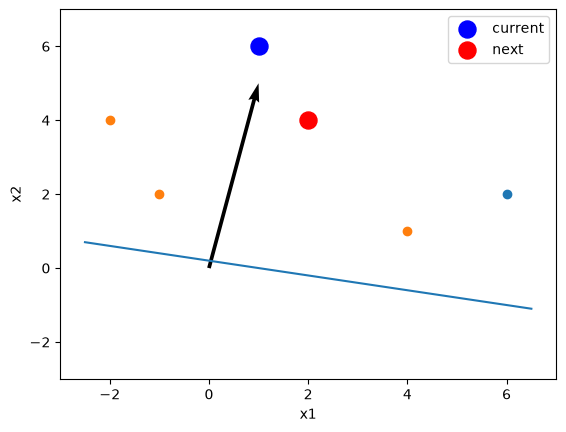

mistake:     [-2  4  1]
new weight:  [ 3.  1. -2.]


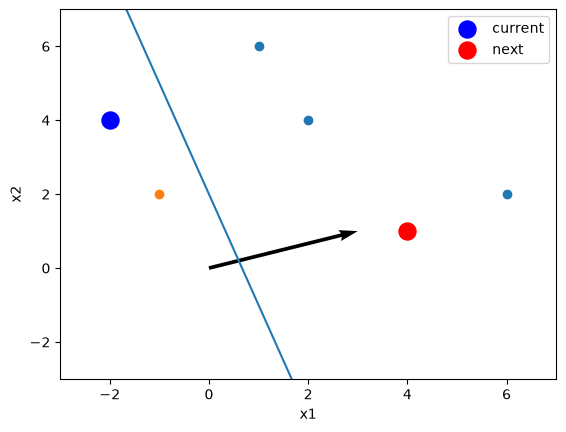

mistake:     [4 1 1]
new weight:  [-1.  0. -3.]


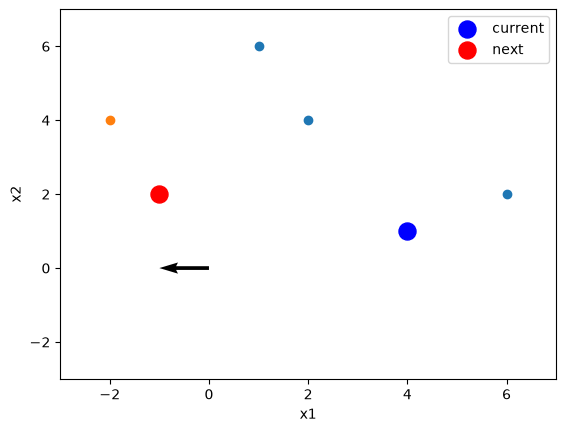

mistake:     [1 6 1]
new weight:  [ 0.  6. -2.]


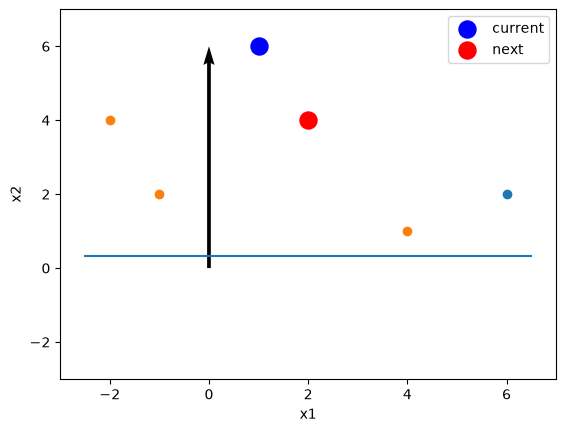

mistake:     [-2  4  1]
new weight:  [ 2.  2. -3.]


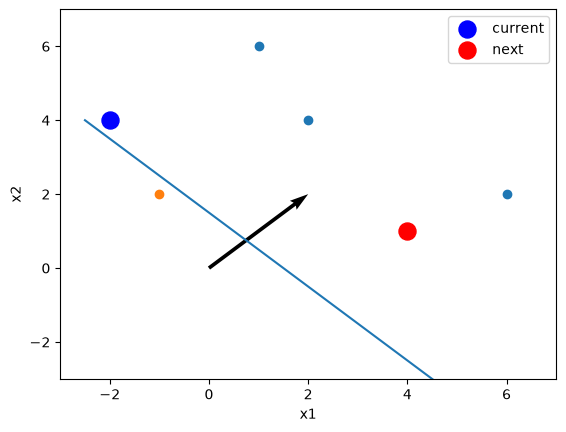

mistake:     [4 1 1]
new weight:  [-2.  1. -4.]


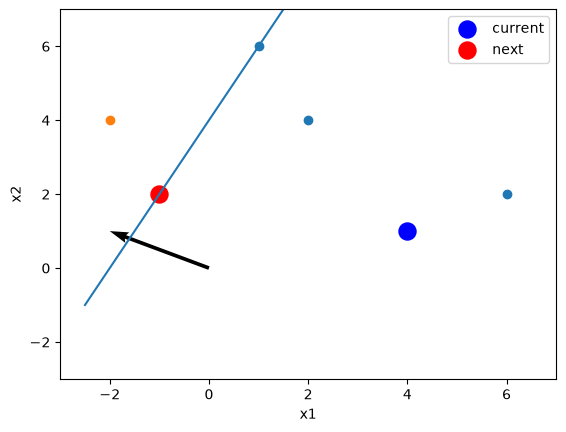

mistake:     [1 6 1]
new weight:  [-1.  7. -3.]


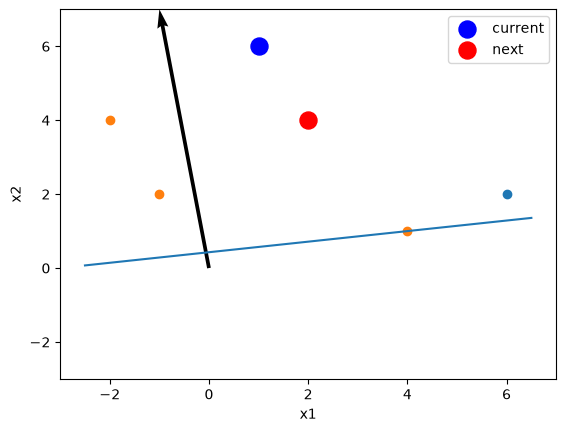

mistake:     [-2  4  1]
new weight:  [ 1.  3. -4.]


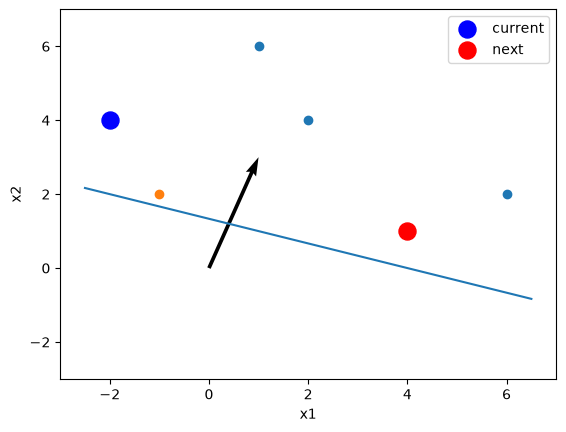

mistake:     [4 1 1]
new weight:  [-3.  2. -5.]


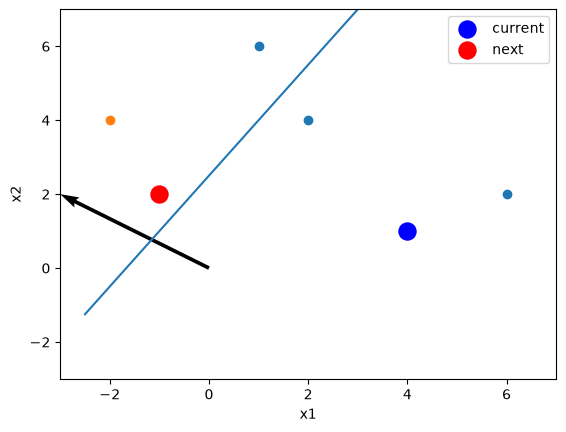

mistake:     [-1  2  1]
new weight:  [-2.  0. -6.]


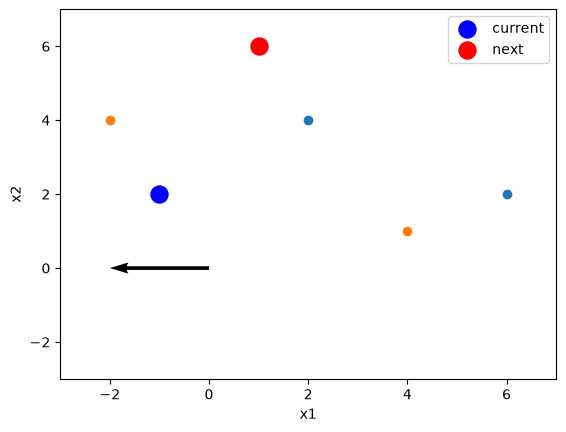

mistake:     [1 6 1]
new weight:  [-1.  6. -5.]


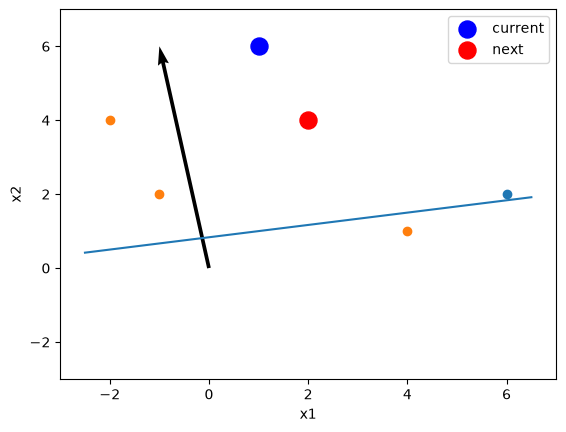

mistake:     [-2  4  1]
new weight:  [ 1.  2. -6.]


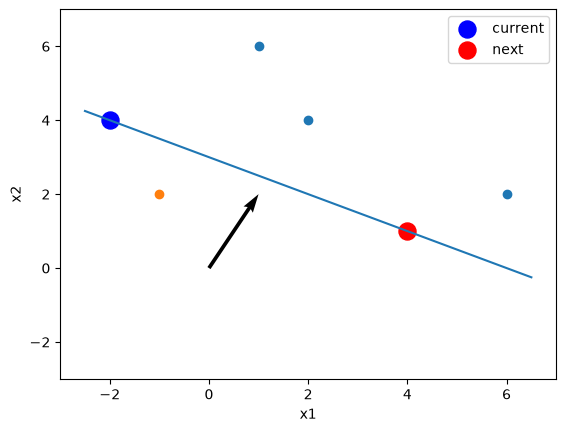

In [75]:
#perceptron algorithm + ploting 
def perceptron(data, label,plot=True):

    #initialize weight and bias
    w = np.zeros(data.shape[1])
    errors = []
    eta = 1

    #classify data
    class_1 = data[label == 1]
    class_2 = data[label == -1]

    for i in range(MAX):

        error = 0

        for i, (x,y) in enumerate(zip(data,label)):
            yi = np.dot(w,x)

            if yi > 0:
                prediction = 1
            else:
                prediction = -1

            if y != prediction:
                error += 1
                w = w + eta * y * x

                if plot:
                    print("mistake:    ", x)
                    print("new weight: ", w)
                    
                    #plot positive
                    plt.scatter(class_1[:,0], class_1[:,1])  
    
                    #plot negative
                    plt.scatter(class_2[:,0], class_2[:,1])  

                    #plot current point 
                    plt.scatter(x[0],x[1], s=150, color = 'blue', label = 'current')
    
                    #plot next point 
                    if i + 1 < len(data):
                        next_x = data[i+1]  
                        plt.scatter(next_x[0],next_x[1], s=150, color = 'red', label = 'next')
    
                    #plot decision boundry
                    xs = np.linspace(data[:,0].min()-0.5, data[:,0].max()+0.5, 200)
                    ys = -(w[0]*xs + w[2]) / (w[1] + 1e-12)
                    plt.plot(xs, ys)  
    
                    #plot weight vector
                    plt.quiver(
                        0, 0,
                        w[0], w[1],
                        angles='xy',
                        scale_units='xy',
                        scale=1
                    )
    
                    plt.xlabel('x1')
                    plt.ylabel('x2')
                    plt.xlim(-3, 7)
                    plt.ylim(-3, 7)
                    plt.legend()
                    plt.show()

        errors.append(error)
            
        if error == 0:
            break 

    return w, errors

w, errors = perceptron(data, label)

Part C:
In total the perceptron made 16 mistakes (k) before it found a possible decission boundry. The theoretical number of mistakes (R/gamma)^2 is much larger at ~1666.5 mistakes. This means that the theorem's bound is not tight, there is a huge gap between the actual number of mistakes versus the theoretical number of possible mistakes.

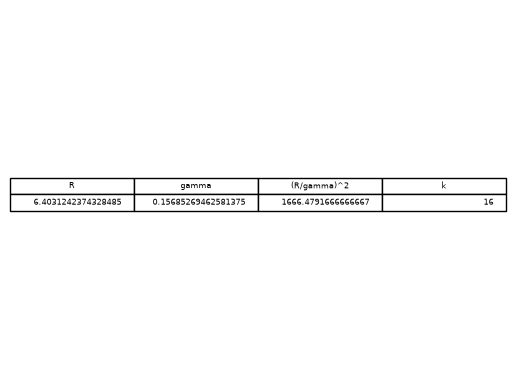

In [11]:
R = np.max(np.linalg.norm(data, axis=1))

W = np.array([0.6875, 1, -4.625])

scores = np.dot(data, W)
margin = np.min(label* scores) / np.linalg.norm(W)

the = (R/margin)**2

labels = ['R','gamma' , '(R/gamma)^2', 'k']
values = [R, margin, the, sum(errors)]
T = plt.table(
              cellText= [values], 
              colLabels= labels,
              loc= 'center'
)
plt.axis('off')
plt.show()


mistake:     [-2  6  1]
new weight:  [-2.  6.  1.]


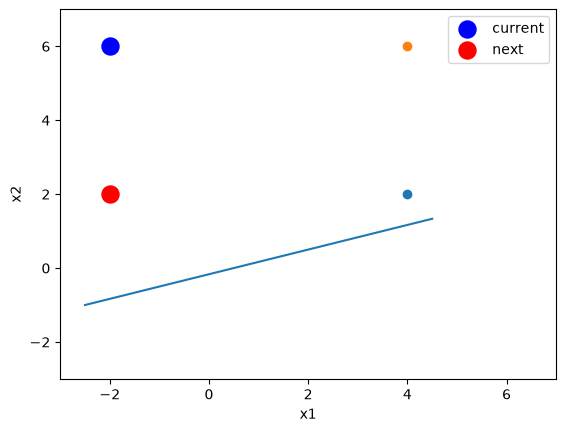

mistake:     [-2  2  1]
new weight:  [0. 4. 0.]


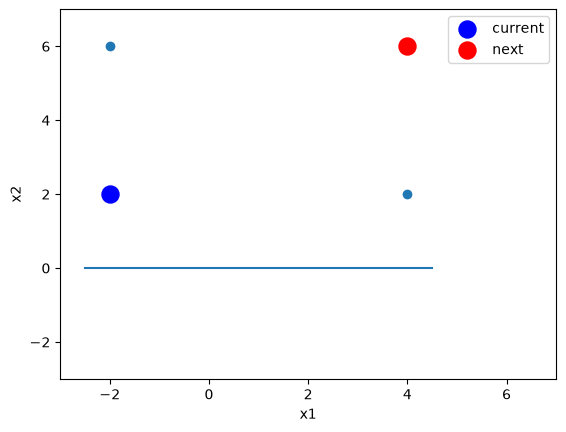

mistake:     [4 6 1]
new weight:  [-4. -2. -1.]


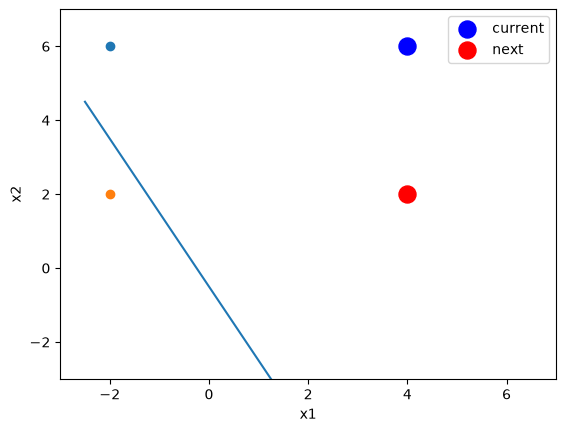

mistake:     [4 2 1]
new weight:  [0. 0. 0.]


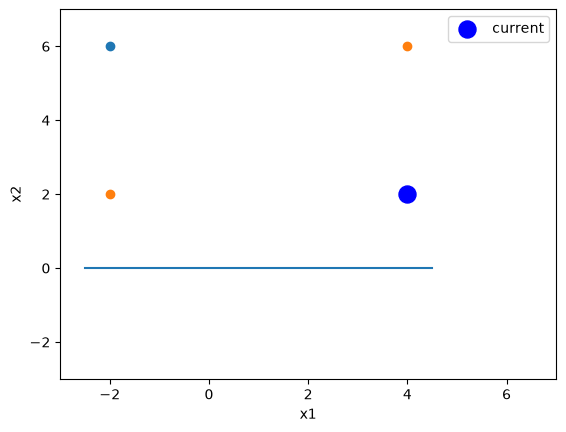

mistake:     [-2  6  1]
new weight:  [-2.  6.  1.]


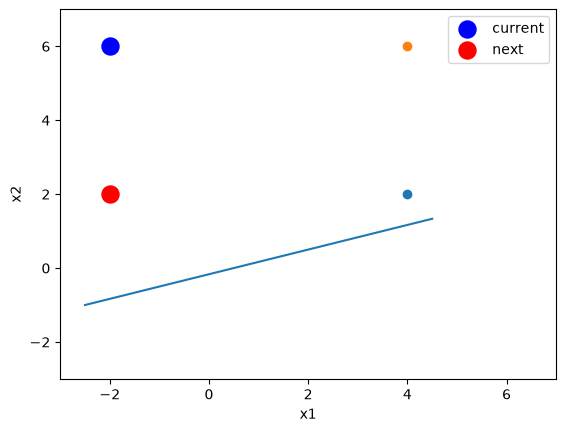

mistake:     [-2  2  1]
new weight:  [0. 4. 0.]


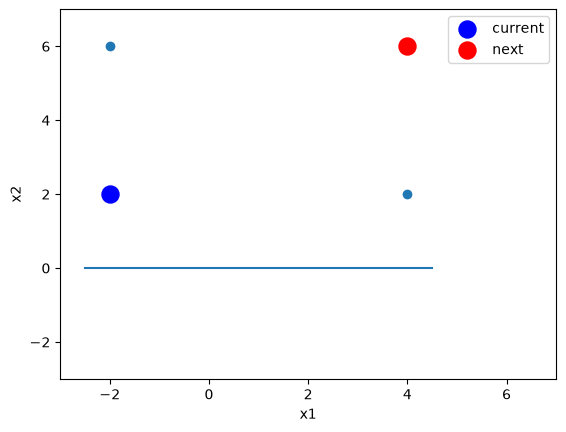

mistake:     [4 6 1]
new weight:  [-4. -2. -1.]


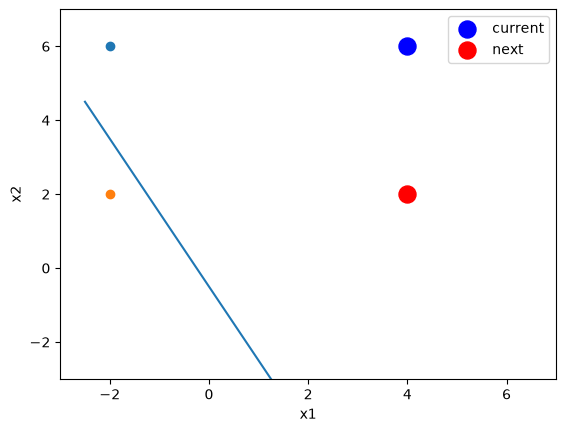

mistake:     [4 2 1]
new weight:  [0. 0. 0.]


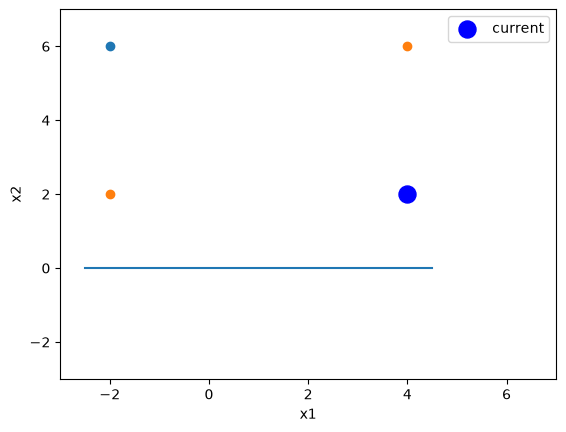

mistake:     [-2  6  1]
new weight:  [-2.  6.  1.]


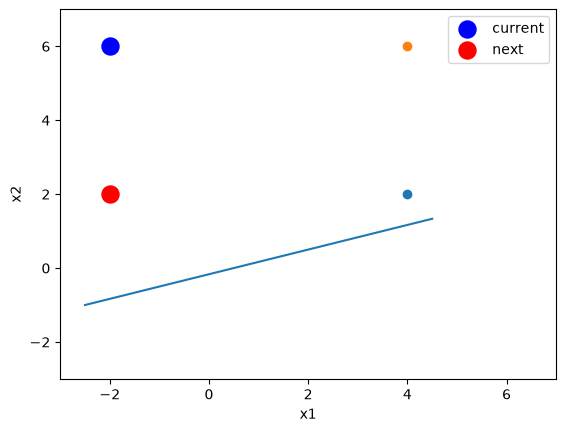

mistake:     [-2  2  1]
new weight:  [0. 4. 0.]


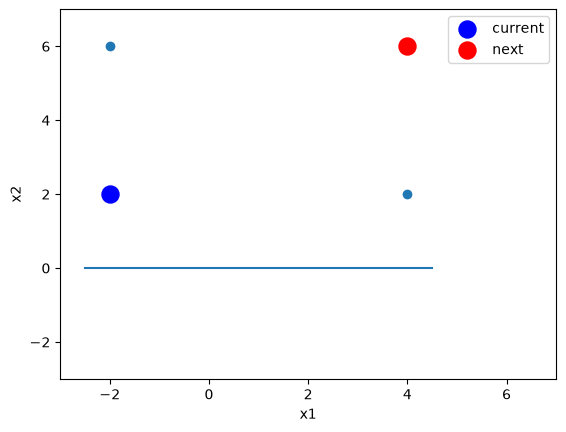

mistake:     [4 6 1]
new weight:  [-4. -2. -1.]


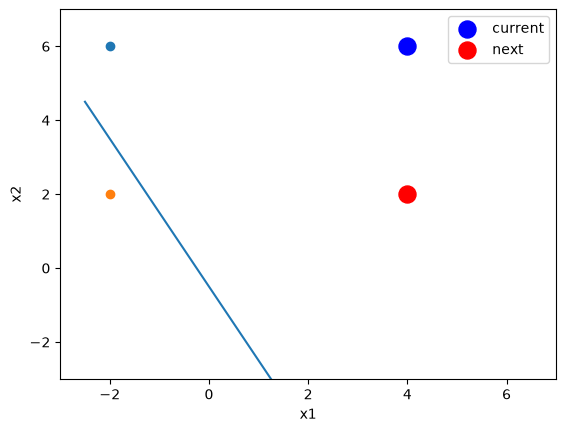

mistake:     [4 2 1]
new weight:  [0. 0. 0.]


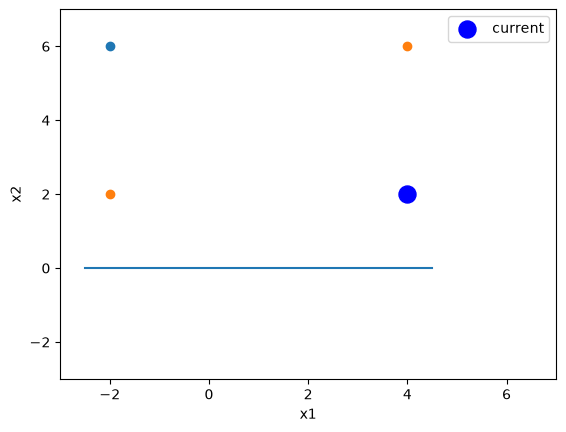

mistake:     [-2  6  1]
new weight:  [-2.  6.  1.]


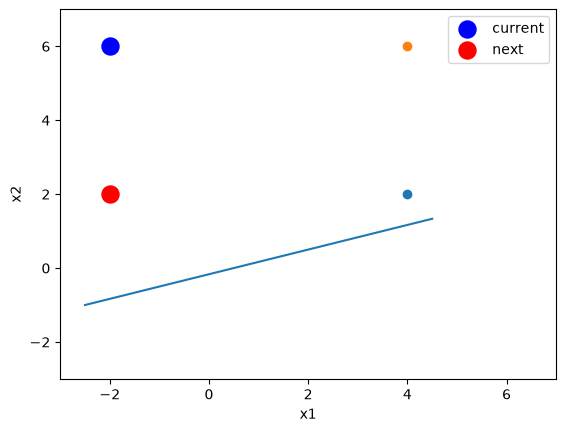

mistake:     [-2  2  1]
new weight:  [0. 4. 0.]


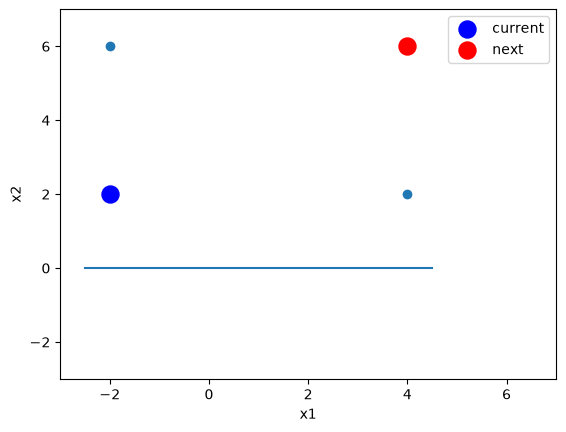

mistake:     [4 6 1]
new weight:  [-4. -2. -1.]


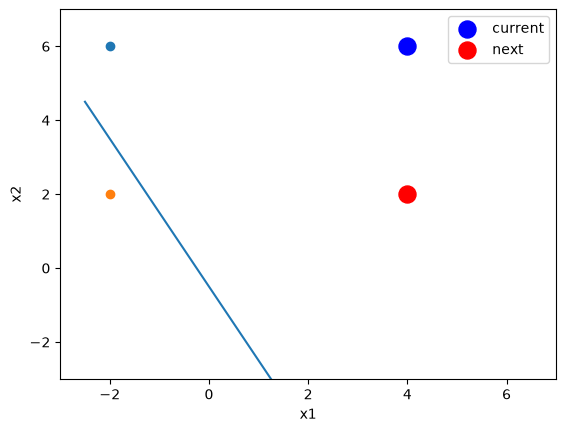

mistake:     [4 2 1]
new weight:  [0. 0. 0.]


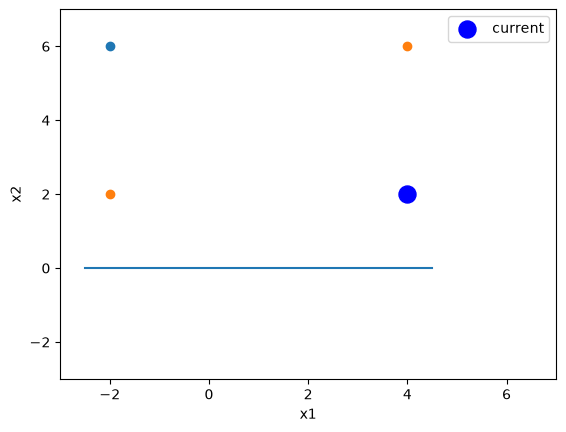

mistake:     [-2  6  1]
new weight:  [-2.  6.  1.]


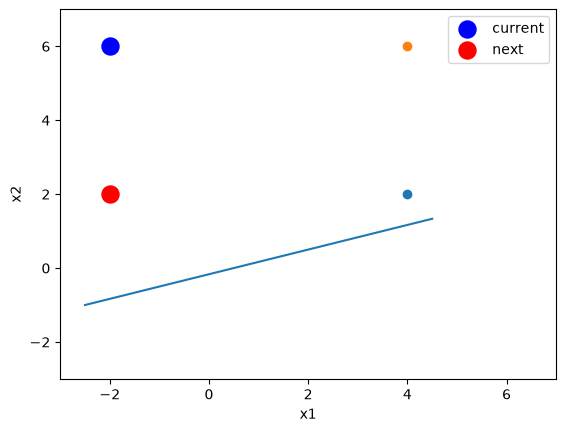

mistake:     [-2  2  1]
new weight:  [0. 4. 0.]


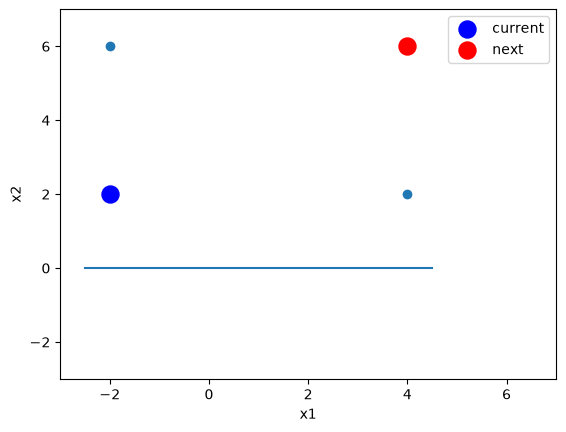

mistake:     [4 6 1]
new weight:  [-4. -2. -1.]


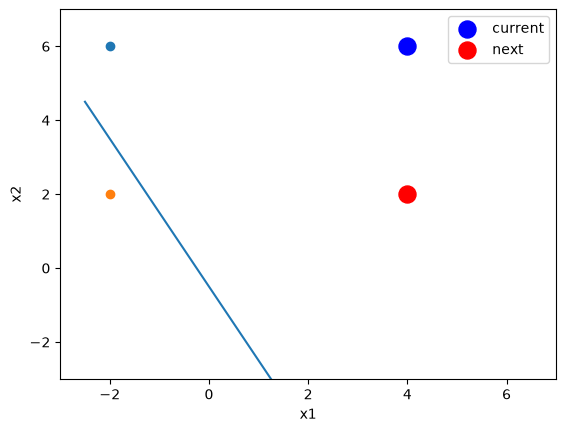

mistake:     [4 2 1]
new weight:  [0. 0. 0.]


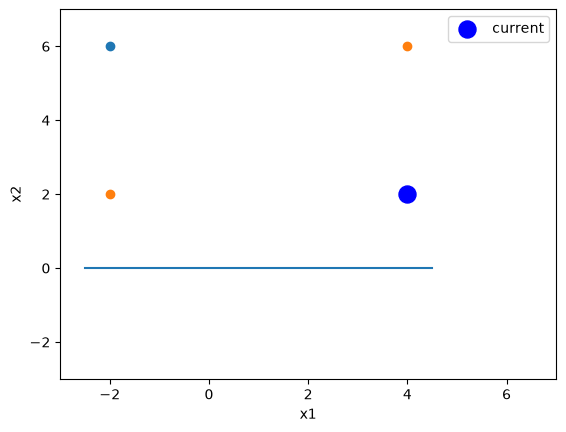

mistake:     [-2  6  1]
new weight:  [-2.  6.  1.]


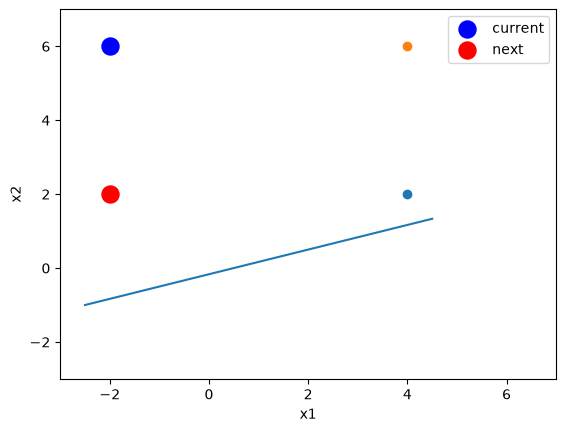

mistake:     [-2  2  1]
new weight:  [0. 4. 0.]


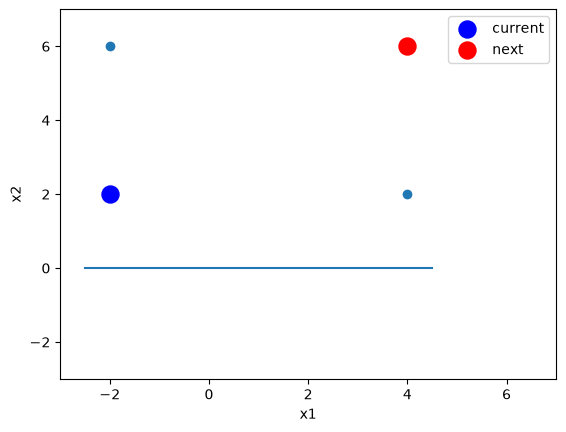

mistake:     [4 6 1]
new weight:  [-4. -2. -1.]


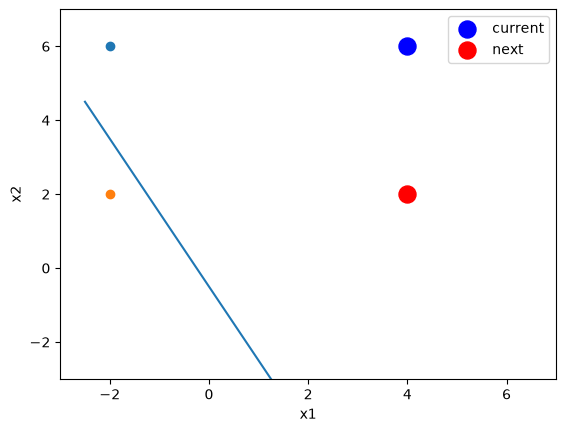

mistake:     [4 2 1]
new weight:  [0. 0. 0.]


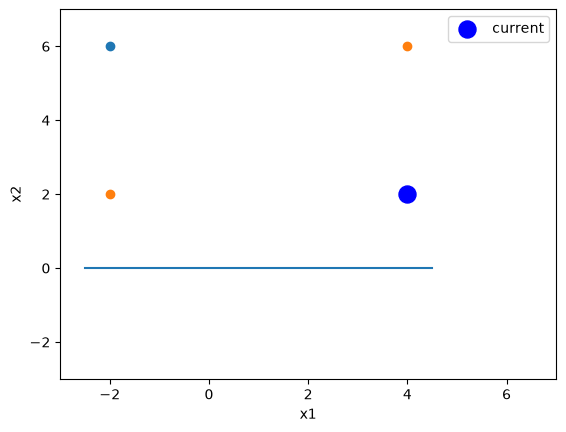

mistake:     [-2  6  1]
new weight:  [-2.  6.  1.]


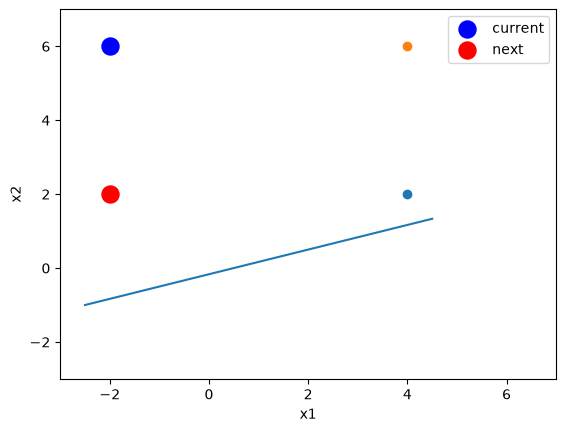

mistake:     [-2  2  1]
new weight:  [0. 4. 0.]


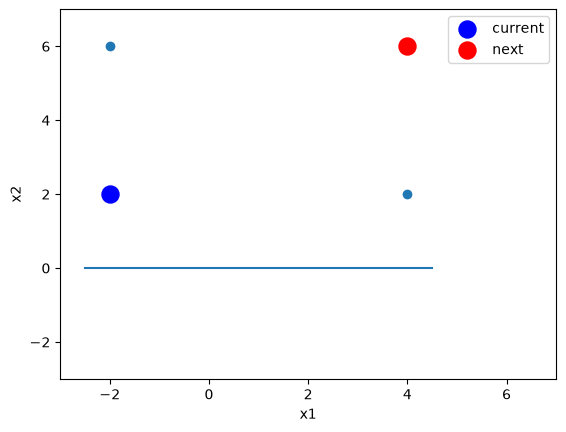

mistake:     [4 6 1]
new weight:  [-4. -2. -1.]


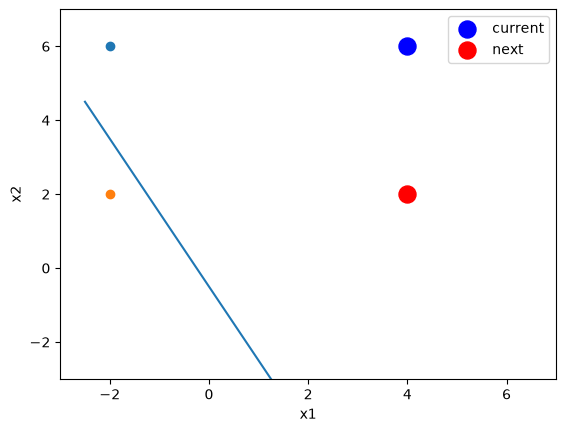

mistake:     [4 2 1]
new weight:  [0. 0. 0.]


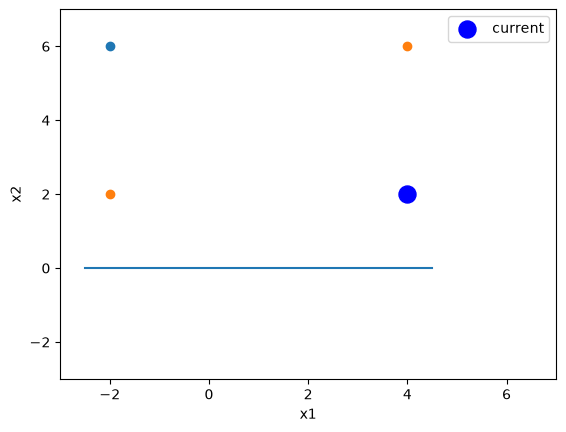

mistake:     [-2  6  1]
new weight:  [-2.  6.  1.]


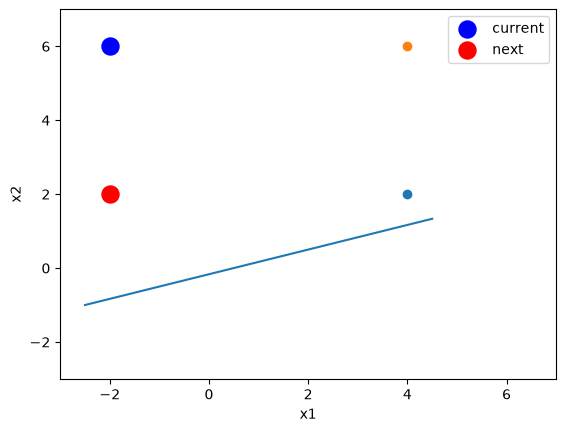

mistake:     [-2  2  1]
new weight:  [0. 4. 0.]


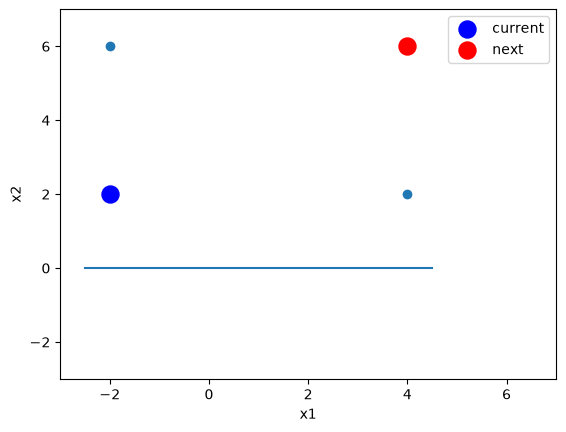

mistake:     [4 6 1]
new weight:  [-4. -2. -1.]


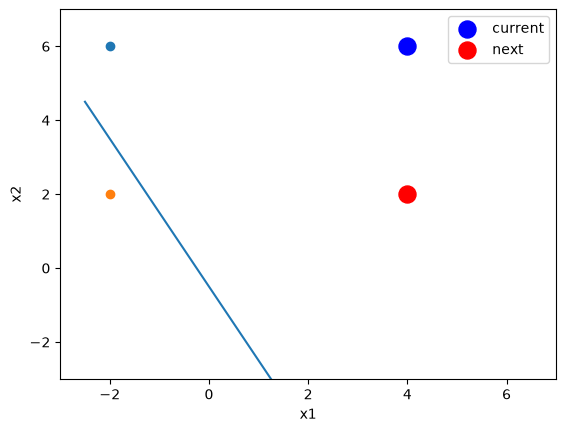

mistake:     [4 2 1]
new weight:  [0. 0. 0.]


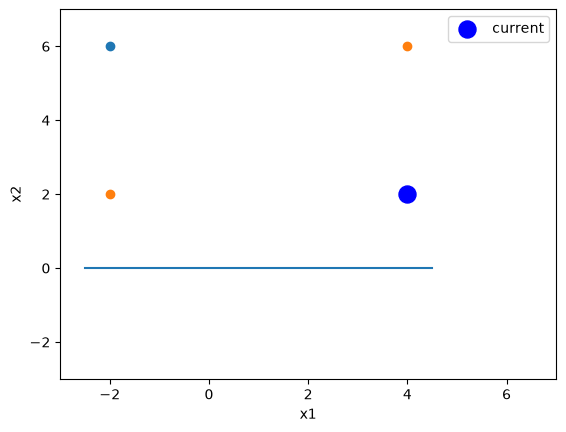

mistake:     [-2  6  1]
new weight:  [-2.  6.  1.]


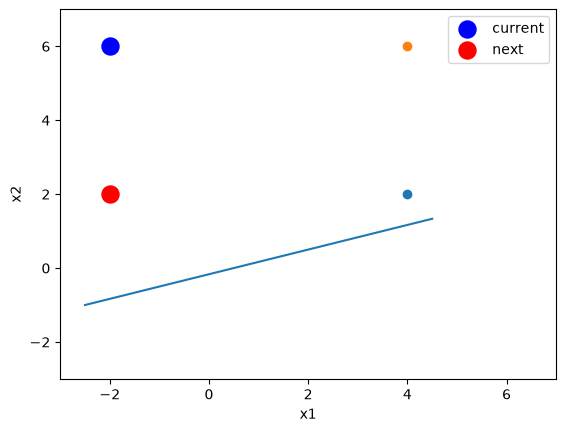

mistake:     [-2  2  1]
new weight:  [0. 4. 0.]


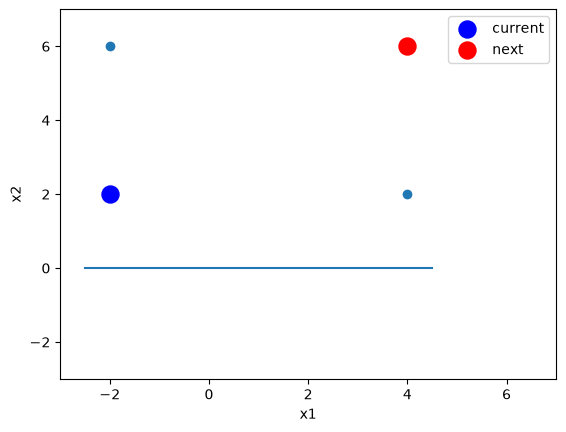

mistake:     [4 6 1]
new weight:  [-4. -2. -1.]


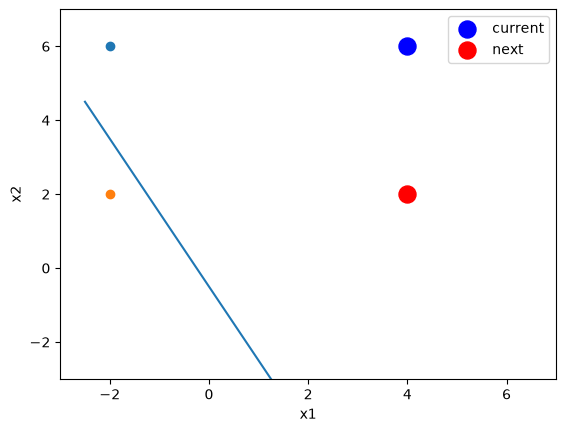

mistake:     [4 2 1]
new weight:  [0. 0. 0.]


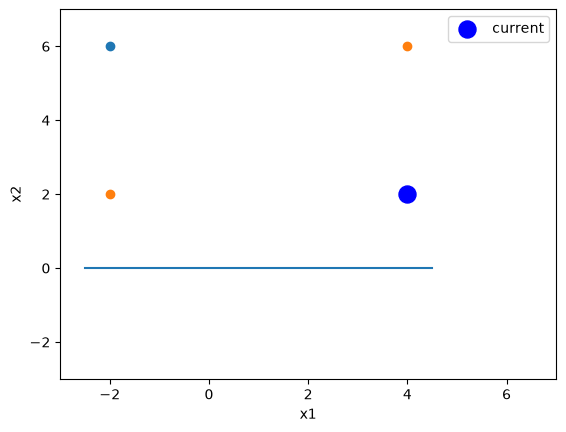

mistake:     [-2  6  1]
new weight:  [-2.  6.  1.]


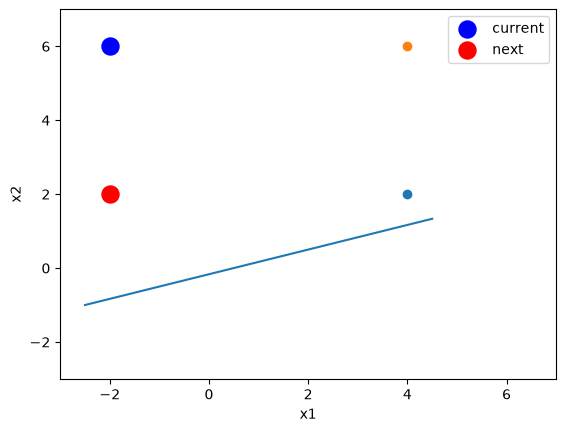

mistake:     [-2  2  1]
new weight:  [0. 4. 0.]


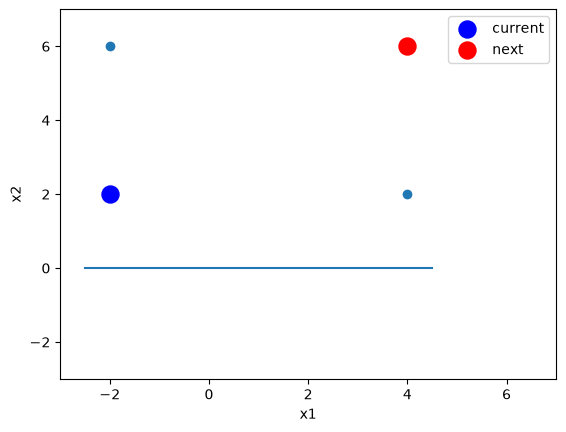

mistake:     [4 6 1]
new weight:  [-4. -2. -1.]


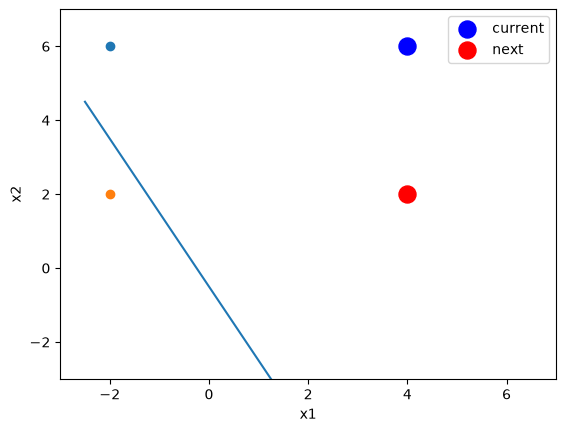

mistake:     [4 2 1]
new weight:  [0. 0. 0.]


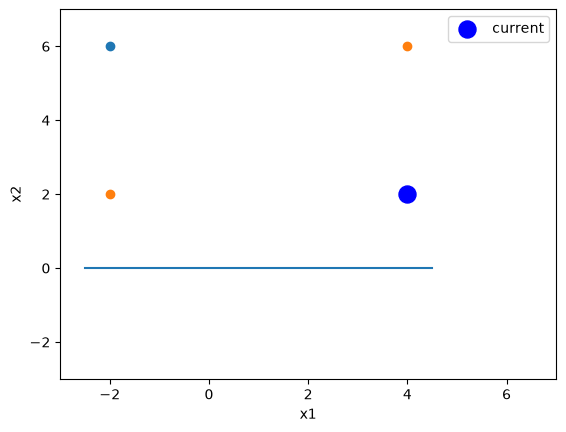

(array([0., 0., 0.]), [4, 4, 4, 4, 4, 4, 4, 4, 4, 4])

In [12]:
XORdata = np.array([
    [-2,6,1],
    [-2,2,1],
    [4,6,1],
    [4,2,1]
])
XORlabel = np.array([1,-1,-1,1])

perceptron(XORdata, XORlabel)

A possible solution to this problem is to transform the non-linearly separable data into a higher dimensinal space where the data becomes linearly separable. By including square features the perceptron is able to find a linear decision bountry in the higher dimensional space then map it back to the original 2D space, which presents it self as a curved line.

weight:  [100. -34. -40.  16.   4. -23.]
errors:  [4, 2, 1, 4, 2, 1, 4, 2, 1, 4, 2, 1, 4, 1, 2, 1, 1, 2, 1, 1, 1, 4, 2, 1, 4, 1, 2, 1, 1, 2, 1, 1, 1, 4, 2, 1, 4, 1, 2, 1, 1, 2, 1, 1, 0]


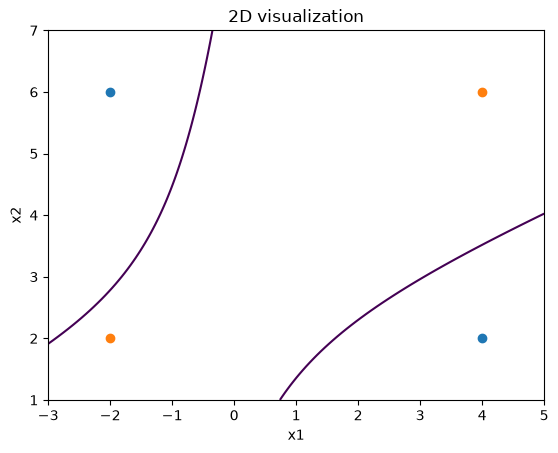

In [56]:
def featuremap(data):
    x1=data[:,0]
    x2=data[:,1]

    return np.column_stack([x1,x2,x1*x2,x1**2,x2**2,np.ones(len(data))])

XORf=featuremap(XORdata)

w, errors = perceptron(XORf, XORlabel, False)

print("weight: ",w)
print("errors: ",errors)

x1 = np.linspace(-3, 5, 100)
x2 = np.linspace(1, 7, 100)

X1, X2 = np.meshgrid(x1, x2)

Z = (w[0]*X1 + 
     w[1]*X2 + 
     w[2]*X1*X2 + 
     w[3]*X1**2 + 
     w[4]*X2**2 + 
     w[5])

plt.contour(X1, X2, Z, levels=[0])

class1 = XORdata[XORlabel == 1]
class2 = XORdata[XORlabel == -1]

plt.scatter(class1[:,0], class1[:,1]) 
plt.scatter(class2[:,0], class2[:,1]) 


plt.title("2D visualization")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [ ]:
Part E: Standardizing features

In [71]:
XORf_standard = XORf.copy()

#standardize every value of the feature map expect for the bias
XORf_standard[:,:-1] = (XORf[:,:-1] - XORf[:,:-1].mean(axis=0)) / XORf[:,:-1].std(axis=0)

w, errors = perceptron(XORf, XORlabel, False)

w_s, errors_s = perceptron(XORf_standard, XORlabel, False)


R = np.max(np.linalg.norm(XORf, axis=1))
R_standard = np.max(np.linalg.norm(XORf_standard, axis=1))

gamma_standard = np.min(XORlabel* np.dot(XORf_standard, w_s)) / np.linalg.norm(w_s)
gamma = np.min(XORlabel* np.dot(XORf, w)) / np.linalg.norm(w)


print("original R: ", R)
print("standardize R: ", R_standard)

print("original gamma: ", gamma)
print("standardized gamma: ", gamma_standard)

print("original errors: ", sum(errors))
print("standardized errors: ", sum(errors_s))

original R:  46.70117771534247
standardize R:  2.678416144567207
original gamma:  0.43801438953952443
standardized gamma:  0.23187262807289427
original errors:  83
standardized errors:  14


The standardized R value is significantly smaller than the original R value, so the distance between the furthest point and the origin got smaller. While the estimated margin got smaller it didn't have a decrease as significant as the R value. The affect on the perceptron was that standardizing the data caused a faster convergence, there were fewer mistakes during training.